<a href="https://colab.research.google.com/github/FebriansyahMonanda83/Data_Science_252420021/blob/main/STUDY_KASUS_252420021.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Load data
df = pd.read_excel('/content/drive/My Drive/DPT_1606/142.xlsx')

# Standardisasi kolom
df.columns = [c.strip().replace(' ', '_').upper() for c in df.columns]

print("Jumlah data:", len(df))
df.head()

Jumlah data: 526372


,KEC_ID,KECAMATAN,KEL_ID,KELURAHAN,DPID,NKK,NIK,NAMA,TEMPAT_LAHIR,TANGGAL_LAHIR,...,K2,K3,UPDATED_AT,STATUS,RANK,TAHAPAN_ID,PROV_ASAL,KAB_ASAL,KEC_ASAL,KEL_ASAL
0,1897,BABAT SUPAT,26685,BABAT BANYUASIN,621119,1304122510190001,1606145511990001,AYU WANDIRA,MUSI BANYUASIN,1999-11-15,...,NaN,NaN,2025-06-12,baru,baru,24,NaN,NaN,NaN,NaN
1,1897,BABAT SUPAT,26685,BABAT BANYUASIN,653479,1371100607070102,1371104303710006,SUSRIANI,SURIAN,1971-03-03,...,NaN,NaN,2025-11-03,baru,baru,26,NaN,NaN,NaN,NaN
2,1897,BABAT SUPAT,26685,BABAT BANYUASIN,590513,1371100801240001,1371102402990001,FINNY FEBRIANYSA,PADANG,1999-02-24,...,NaN,NaN,2024-08-03,baru,baru,2,NaN,NaN,NaN,NaN
3,1897,BABAT SUPAT,26685,BABAT BANYUASIN,590514,1371100801240001,1304103108950001,ASMAKA INSIA,MALINTANG,1995-08-31,...,NaN,NaN,2024-08-03,baru,baru,2,NaN,NaN,NaN,NaN
4,1897,BABAT SUPAT,26685,BABAT BANYUASIN,7972,1402070601130002,1402070412570001,USMAN,BANYUASIN,1957-12-04,...,NaN,NaN,2024-06-07,aktif,aktif,1,NaN,NaN,NaN,NaN


In [7]:
# Konversi tanggal lahir
df['TANGGAL_LAHIR'] = pd.to_datetime(df['TANGGAL_LAHIR'], errors='coerce')

# Hapus data tidak valid
df = df.dropna(subset=['TANGGAL_LAHIR'])

# Hitung usia
df['USIA'] = 2026 - df['TANGGAL_LAHIR'].dt.year

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
# Kategori generasi
def kategori_gen(u):
    if u <= 27: return 'Gen Z'
    elif u <= 43: return 'Milenial'
    elif u <= 59: return 'Gen X'
    else: return 'Baby Boomer'

df['GENERASI'] = df['USIA'].apply(kategori_gen)

# Disabilitas
map_dis = {
    '0': 'Non', '1': 'Fisik', '2': 'Intelektual',
    '3': 'Mental', '4': 'Wicara', '5': 'Rungu', '6': 'Netra'
}

df['DISABILITAS'] = df['DISABILITAS'].fillna('0').astype(str)
df['LABEL_DISABILITAS'] = df['DISABILITAS'].map(map_dis)
df['IS_DISABILITAS'] = df['DISABILITAS'].apply(lambda x: 0 if x == '0' else 1)

In [9]:
tps = df.groupby('TPS').agg({
    'NIK': 'count',
    'IS_DISABILITAS': 'sum',
    'USIA': 'mean'
}).rename(columns={
    'NIK': 'TOTAL_PEMILIH',
    'USIA': 'RATA_USIA'
})

tps['PROPORSI_DISABILITAS'] = tps['IS_DISABILITAS'] / tps['TOTAL_PEMILIH']

In [10]:
tps = df.groupby('TPS').agg({
    'NIK': 'count',
    'IS_DISABILITAS': 'sum',
    'USIA': 'mean'
}).rename(columns={
    'NIK': 'TOTAL_PEMILIH',
    'USIA': 'RATA_USIA'
})

tps['PROPORSI_DISABILITAS'] = tps['IS_DISABILITAS'] / tps['TOTAL_PEMILIH']

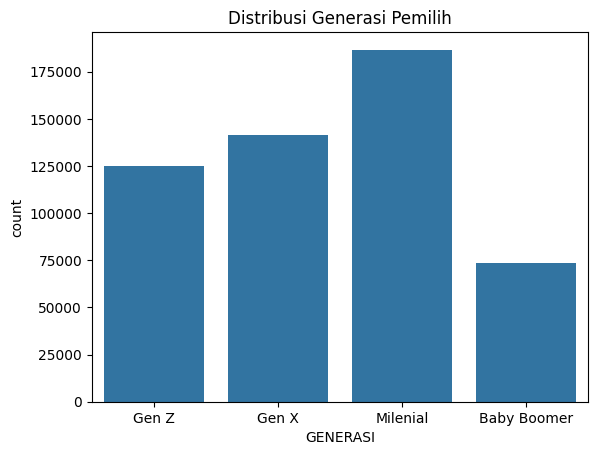

In [11]:
sns.countplot(data=df, x='GENERASI')
plt.title("Distribusi Generasi Pemilih")
plt.show()

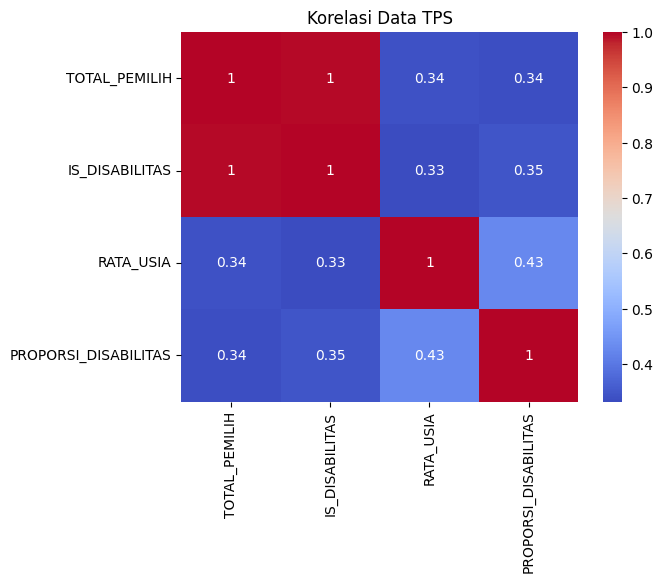

In [12]:
sns.heatmap(tps.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Korelasi Data TPS")
plt.show()

In [13]:
np.random.seed(42)

tps['DURASI'] = (
    tps['TOTAL_PEMILIH'] * 2 +
    tps['IS_DISABILITAS'] * 3 +
    tps['RATA_USIA'] * 0.1 +
    np.random.normal(0, 10, len(tps))
)

In [14]:
X = tps[['TOTAL_PEMILIH', 'IS_DISABILITAS', 'PROPORSI_DISABILITAS', 'RATA_USIA']]
y = tps['DURASI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [15]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.9999999951256909
MAE: 5.89452430466864


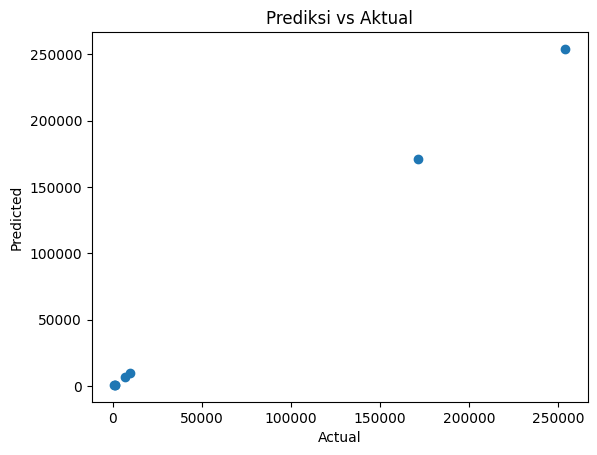

In [16]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Prediksi vs Aktual")
plt.show()

In [18]:
turnout = {
    'Gen Z': 0.70,
    'Milenial': 0.75,
    'Gen X': 0.85,
    'Baby Boomer': 0.90
}

def simulasi(df, n=300):
    hasil = []
    for _ in range(n):
        hadir = df['GENERASI'].apply(
            lambda g: 1 if np.random.rand() < turnout[g] else 0
        ).sum()
        hasil.append(hadir)
    return hasil

hasil_simulasi = simulasi(df)

print("Rata-rata hadir:", int(np.mean(hasil_simulasi)))

Rata-rata hadir: 413726
